### Chains Using Langgraphs

- how ro use chat messages as our graph state
- how to use chat models in graph nodes
- how to bind tools to our LLM in chat models
- how to execute the tools call in our graph nodes

In [64]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [65]:
## part 1- Messages
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

from pprint import pprint

messages=[AIMessage(content=f"How can i help u?", name="LLMModel")]

messages.append(HumanMessage(content=f"I want to know more about you!", name="Shreyas"))

messages.append(AIMessage(content=f"Sure, I am a language model created by OpenAI.", name="LLMModel"))

messages.append(HumanMessage(content=f"Can u explain me the Transformer model", name="Shreyas"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

How can i help u?
================================ Human Message =================================
Name: Shreyas

I want to know more about you!
================================== Ai Message ==================================
Name: LLMModel

Sure, I am a language model created by OpenAI.
================================ Human Message =================================
Name: Shreyas

Can u explain me the Transformer model


In [66]:
## Chat Models
from langchain_groq import ChatGroq 
llm= ChatGroq(model="gemma2-9b-it")
result=llm.invoke(messages)

In [67]:
result.response_metadata

{'token_usage': {'completion_tokens': 408,
  'prompt_tokens': 62,
  'total_tokens': 470,
  'completion_time': 0.741818182,
  'prompt_time': 0.003821419,
  'queue_time': 0.25957032,
  'total_time': 0.745639601},
 'model_name': 'gemma2-9b-it',
 'system_fingerprint': 'fp_10c08bf97d',
 'finish_reason': 'stop',
 'logprobs': None}

### tools
tools are the third party systems which are integrated in our llm model which can be used during or in the chat


we used Routers here which helps us in deciding in when to use and when to not use the tools

here we will be binding our llms to the tools

In [68]:
from langchain.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two integers and return the result."""
    return a + b


In [69]:
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000002AFC0D0CD10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002AFC0C6DA90>, model_name='gemma2-9b-it', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [70]:
### binding tool with llm

llm_with_tools=llm.bind_tools([add])

tool_call=llm_with_tools.invoke([HumanMessage(content=f"What is 2+2?", name="Shreyas")])

In [71]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': '6885js1zs',
  'type': 'tool_call'}]

### using messages as state

## reducers
Reducers are used here so that the messages dont override and we can have track of the previous sessions chats

In [72]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    message:Annotated[list[AnyMessage], add_messages]


### reducers with add_messages

In [73]:
initial_messages=[AIMessage(content=f"How can i help u?", name="LLMModel")]

initial_messages.append(HumanMessage(content=f"I want to know more about you!", name="Shreyas"))



In [74]:
ai_message=AIMessage(content=f"Sure, I am a language model created by OpenAI.", name="LLMModel")
ai_message

AIMessage(content='Sure, I am a language model created by OpenAI.', additional_kwargs={}, response_metadata={}, name='LLMModel')

In [75]:
add_messages(initial_messages, ai_message)

[AIMessage(content='How can i help u?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='19700751-fe23-4e15-af98-7c4b450c1e4f'),
 HumanMessage(content='I want to know more about you!', additional_kwargs={}, response_metadata={}, name='Shreyas', id='de7714f0-4544-44e2-8d08-f2fcabffb358'),
 AIMessage(content='Sure, I am a language model created by OpenAI.', additional_kwargs={}, response_metadata={}, name='LLMModel', id='748053ab-2703-4017-a177-fc366867f213')]

In [76]:
## cgatbot node functianlity
def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["message"])]}

In [77]:
from IPython.display import display,Image
from langgraph.graph import StateGraph, START,END
builder=StateGraph(State)

builder.add_node(
    "llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")

builder.add_edge("llm_tool", END)

graph=builder.compile()

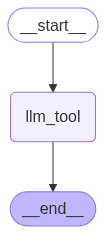

In [78]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [79]:
## invokation

messages=graph.invoke({"messages":"what is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

BadRequestError: Error code: 400 - {'error': {'message': "'messages' : minimum number of items is 1", 'type': 'invalid_request_error'}}